In [1]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

#jax.config.update("jax_enable_x64", True)

import optax
import flax.linen as nn
from flax.training.train_state import TrainState
 
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from toolbox import *

In [2]:
seed = 1234
key = jax.random.key(seed)

## Problem parameters

#### Static constants

In [3]:
mu_qub = 4.0
mu_cav = 8.0

In [4]:
k = 2 #quartic bsplines (only 3 non zero bsplines simultaneously)
bspln_num = 20    # Desired number of basis pulses

# Skip exactly 'k' on both sides to use purely uniform interior splines
skip_left = k
skip_right = k
n = bspln_num + skip_left + skip_right  # Total knots required = 24


# Grid interval (delta) must be a multiple of 4ns. 
delta_ns = 64
m = n - k  # Total uniform intervals = 22

T_ns_hw = m * delta_ns
T_us_hw = T_ns_hw / 1000.0

time_start = 0.0
time_end = T_us_hw

# A degree k B-spline spans exactly k+1 intervals
L_ns = (k + 1) * delta_ns  


print("--- Pulse Properties ---")
print(f"B-spline Degree (k)     : {k}")
print(f"Grid step (delta_ns)    : {delta_ns} ns")
print(f"Single pulse length     : {L_ns} ns")
print(f"Total sequence duration : {T_ns_hw} ns ({T_us_hw} us)")
print(f"Max overlapping pulses  : {k + 1}")
print("------------------------")
assert L_ns % 4 == 0, "Pulse length is not a multiple of 4 ns!"

--- Pulse Properties ---
B-spline Degree (k)     : 2
Grid step (delta_ns)    : 64 ns
Single pulse length     : 192 ns
Total sequence duration : 1408 ns (1.408 us)
Max overlapping pulses  : 3
------------------------


In [5]:
t_drive = T_us_hw
ndt_drive = 200

num_bspln = bspln_num 
num_bspln

20

In [6]:
inp_shape = (1,)
osz = num_bspln * 4
rec_features = osz
dense_features = [osz * 2, osz * 3, osz * 2]
learning_rate=0.002

rec_features, dense_features

(80, [160, 240, 160])

#### Dynamic const

In [7]:
N_cav = 28
chi =  0.6641440162100237 * (2 * jnp.pi)

t1_qub = 48.3
t2_qub = 33.0
t1_cav = 237.0

t_idle = 20

In [8]:
psi_target_cav = basis(N_cav, 2) + basis(N_cav, 3)
psi_target_cav /= jnp.sqrt(hconj(psi_target_cav) @ psi_target_cav)

## Driven Hamiltonian

In [9]:
def build_drive_htree(N_cav, chi, e_qub, e_cav):
    a = tensor(identity(2), destroy(N_cav))
    adag = hconj(a)
    n_phot = adag @ a
    sigz = tensor(sigma.z, identity(N_cav))
    sigp = tensor(sigma.p, identity(N_cav))
    one = tensor(identity(2), identity(N_cav))

    H_drift = +(chi / 2) * n_phot @ (sigz + one)
    
    ht = [
        [H_drift, 1, 1, 0],
        [mu_qub * sigp, e_qub, 1, 1],
        [mu_cav * adag, e_cav, 1, 1]
    ]
    return ht

def get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt):
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)
    hmat = hmat_from_htree(htree)
    return evol_hdt_exp(hmat, dt)

def make_drive(N_cav, chi):
    
    def drive(rho_init, es_qub, es_cav, dts):
        
        def f(rho, x):
            e_qub, e_cav, dt = x
            uevol = get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt)[0]
            return uevol @ rho @ hconj(uevol), None
    
        rho_fin, _ = jax.lax.scan(f, rho_init, [es_qub, es_cav, dts])
        return rho_fin
    
    return drive

## Time-grids and B-splines

In [10]:
t_drive_edges = jnp.linspace(0, t_drive, ndt_drive + 1)
t_drive_mids = (t_drive_edges[1:] + t_drive_edges[:-1]) / 2
t_drive_intvs = t_drive_edges[1:] - t_drive_edges[:-1]

In [11]:
bspline_builder = setup_bspline_builder(0, t_drive_edges[-1], n, k, skip_left, skip_right)

bsplns_mids = bspline_builder(t_drive_mids)
bsplns_edges = bspline_builder(t_drive_edges)

knots = bknots_on_interval(0, t_drive_edges[-1], n, k)
knots = np.unique(knots)

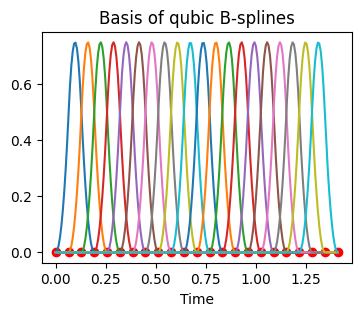

In [12]:
# TEST
fig, ax = plt.subplots(figsize=(4, 3))

for i in range(bsplns_edges.shape[0]):
    ax.plot(t_drive_edges, bsplns_edges[i])
        
ax.scatter(knots, np.zeros_like(knots), color="red");   
ax.set_xlabel("Time");
ax.set_title("Basis of qubic B-splines");
# TEST

In [13]:
def ctrl_from_coeffs(ctrl_coeffs, bsplns):
    ctrls_real = ctrl_coeffs @ bsplns
    e_qub = ctrls_real[0, ...] + 1j * ctrls_real[1, ...]
    e_cav = ctrls_real[2, ...] + 1j * ctrls_real[3, ...]
    return e_qub, e_cav

## Relaxation

In [14]:
def liouv_relax_channel(c):
    l = tensor(c, c.conj())
    l -= 1 / 2 * tensor(hconj(c) @ c, identity(len(c)))
    l -= 1 / 2 * tensor(identity(len(c)), (hconj(c) @ c).T)
    return l

def eval_idling_matrix(cs, t):
    l = sum(liouv_relax_channel(c) for c in cs)
    return jsp.linalg.expm(l * t)

def build_c_ops(N_cav, t1_qub, t2_qub, t1_cav):
    get_t_phi_qub = lambda t1, t2: 1 / ((1 / t2) - (1 / t1) / 2)
    t_phi_qub = get_t_phi_qub(t1_qub, t2_qub)

    sigm = tensor(sigma.m, identity(N_cav))
    sigz = tensor(sigma.z, identity(N_cav))
    a = tensor(identity(2), destroy(N_cav))
    
    c_ops = [
        1 / jnp.sqrt(t1_qub) * sigm,
        1 / jnp.sqrt(t_phi_qub) * sigz / jnp.sqrt(2),
        1 / jnp.sqrt(t1_cav) * a
    ]
    return c_ops

def make_idle(N_cav, t1_qub, t2_qub, t1_cav, t):
    cs = build_c_ops(N_cav, t1_qub, t2_qub, t1_cav)
    idling_matrix = eval_idling_matrix(cs, t)

    def idle(rho):
        rho_liouv = rho.reshape(-1, 1)
        rho_liouv = idling_matrix @ rho_liouv
        return rho_liouv.reshape(rho.shape)

    return idle

## Measurement with qubit reset

In [15]:
def measure_sz(key, rho_init):
    probs = rho_init.diagonal().reshape(2, -1).sum(axis=1).real
    outcome_indx = jax.random.choice(key, 2, p=probs)
    prob = probs[outcome_indx]
    
    idx_mid = rho_init.shape[-1] // 2
    rho_fin_cav = jnp.where(outcome_indx == 0, rho_init[:idx_mid, :idx_mid], rho_init[idx_mid:, idx_mid:])
    
    # Qubit rest
    rho_fin_qub = basis(2, 1) @ hconj(basis(2, 1))
    
    rho_fin = tensor(rho_fin_qub, rho_fin_cav)
    rho_fin /= jnp.trace(rho_fin)
    
    # Outcome definition
    outcome = 2 * outcome_indx - 1
    
    return outcome, prob, rho_fin

## Fidelity of the cavity state

In [16]:
def make_fidelity_cav(psi_target_cav):

    def fidelity_cav(rho):
        idx_mid = rho.shape[-1] // 2
        rho_cav = rho[:idx_mid, :idx_mid] + rho[idx_mid:, idx_mid:]
        return (hconj(psi_target_cav) @ rho_cav @ psi_target_cav)[0][0].real

    return fidelity_cav

## RNN

In [17]:
def init_carry(key, rec_features, inp_shape):
    gru_cell = nn.GRUCell(features=rec_features)
    return gru_cell.initialize_carry(key, inp_shape)

def create_flax_state(key,
                      rec_features, dense_features,
                      inp_shape, learning_rate,
                      *, print_summary):
    
    class Model(nn.Module):
    
        @nn.compact
        def __call__(self, carry, x):
            
            gru_cell = nn.GRUCell(features=rec_features)
            carry, x = gru_cell(carry, x)
            
            for ndf in dense_features:
                x = nn.Dense(ndf)(x)
                x = jax.nn.relu(x)
                
            out_layer = nn.Dense(4 * num_bspln)
            x = out_layer(x)
            x = x.reshape(4, num_bspln)
            
            return carry, x

    model = Model()

    fake_key = jax.random.key(0)
    fake_carry = init_carry(fake_key, rec_features, inp_shape)
    fake_inp = jnp.ones(inp_shape)
    params = model.init(key, fake_carry, fake_inp)["params"]

    optimizer = optax.adam(learning_rate=learning_rate)

    flax_state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

    if print_summary:
        print(model.tabulate(fake_key, fake_carry, fake_inp))

    return flax_state

def apply_nn(flax_state, params, carry, inp):
    return flax_state.apply_fn({'params': params}, carry, inp)



In [18]:
key, subkey = jax.random.split(key)
flax_state = create_flax_state(
    subkey, rec_features, dense_features, inp_shape, learning_rate,
    print_summary=True
)


                                 Model Summary                                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ path         ┃ module  ┃ inputs        ┃ outputs         ┃ params            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│              │ Model   │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[4,20] │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0    │ GRUCell │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[80]   │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0/ir │ Dense   │ float32[1]    │ float32[80]     │ bias: float32[80] │
│              │         │               │                 │ kernel:           │
│              │         │ 

## Time step  
- 1) Measurement
- 2) Fidelity
- 3) Idling (decay)
- 3) RNN interrogation
- 3) Qubit reset

In [19]:
def make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    fidelity_cav = make_fidelity_cav(psi_target_cav)
    idle = make_idle(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
    drive = make_drive(N_cav, chi)
    
    def time_step(key, rho, flax_state, params, carry):
        meas_out, prob, rho = measure_sz(key, rho)
        fid = fidelity_cav(rho)
        rho = idle(rho)
        rnn_inp = jnp.array([meas_out], dtype=float)
        carry, ctrl_coeffs = apply_nn(flax_state, params, carry, rnn_inp)
        es_qub, es_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)
        rho = drive(rho, es_qub, es_cav, t_drive_intvs)  
        return rho, carry, fid, meas_out, prob
    
    return time_step

## Trajectory

In [20]:
def make_trajectory(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    time_step = make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav)
    
    def trajectory(key, flax_state, params, num_time_steps):
        
        def f(scan_carry, _):
            key, rho, carry = scan_carry
            key, subkey = jax.random.split(key)
            rho, carry, fid, meas_out, prob = time_step(subkey, rho, flax_state, params, carry)
            y = fid, meas_out, prob
            scan_carry = key, rho, carry
            return scan_carry, y
        
        key1, key2 = jax.random.split(key)
        carry = init_carry(key1, rec_features, inp_shape)
        psi_init = tensor(basis(2, 1), psi_target_cav)
        scan_carry = key2, psi_init @ hconj(psi_init), carry
        _, ys = jax.lax.scan(f, scan_carry, length=num_time_steps)
        return ys
    
    return trajectory

## Trajectory with reward gradients

In [21]:
def make_trajectory_with_rewgrad(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    
    trajectory = make_trajectory(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav)
    
    def trajectory_with_rewgrad(key, flax_state, num_time_steps):
    
        def func(params):
            traj_out = trajectory(key, flax_state, params, num_time_steps)
            fid, meas_out, prob = traj_out
            rew = -jnp.log(1 - fid.mean())
            log_prob = jnp.log(prob).sum()
            return rew + jax.lax.stop_gradient(rew) * log_prob, traj_out
    
        grad_func = jax.grad(func, has_aux=True)
        rewgrad, traj_out = grad_func(flax_state.params)
        return rewgrad, traj_out
    
    return trajectory_with_rewgrad

## Train on batch

In [22]:
def make_train_on_batch(
        N_cav, chi,
        t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        batch_size, num_time_steps
    ):
    
    trajectory_with_rewgrad = make_trajectory_with_rewgrad(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
    )
    
    trajectory_with_rewgrad_vec = jax.vmap(
            trajectory_with_rewgrad, in_axes=(0, None, None)
        )
    
    @jax.jit
    def train_on_batch(key, flax_state):
        keys = jax.random.split(key, batch_size)
        rewgrad, traj_out = trajectory_with_rewgrad_vec(keys, flax_state, num_time_steps)
        lossgrad = jax.tree.map(lambda x: -x.mean(axis=0), rewgrad)
        flax_state = flax_state.apply_gradients(grads=lossgrad) 
        return flax_state, traj_out
    
    return train_on_batch

## Test on batch

In [23]:
def make_test_on_batch(
        N_cav, chi,
        t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        batch_size, num_time_steps
    ):
    
    trajectory = make_trajectory(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
    )
    
    trajectory_vec = jax.vmap(
            trajectory, in_axes=(0, None, None, None)
        )
    
    @jax.jit
    def test_on_batch(key, flax_state):
        keys = jax.random.split(key, batch_size)
        traj_out = trajectory_vec(keys, flax_state, flax_state.params, num_time_steps)
        return traj_out
    
    return test_on_batch

## >>> Run

In [24]:
num_time_steps_train = 15
num_time_steps_test = 150
batch_size = 32

In [25]:
train_on_batch = make_train_on_batch(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav, batch_size, num_time_steps_train)

test_on_batch = make_test_on_batch(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav, batch_size, num_time_steps_test)

In [26]:
mean_fids_train = []

In [ ]:
for i in range(1000):
    key, subkey = jax.random.split(key)
    flax_state, traj_out = train_on_batch(subkey, flax_state)
    fids, meas_outs, probs = traj_out
    mean_fid = fids.mean()
    mean_fids_train.append(mean_fid)

    print("i =",i,"    fid =",mean_fid)

2026-04-20 14:55:16.066304: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-20 14:55:16.066341: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-20 14:55:16.066352: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-20 14:55:16.066361: W external/xla/xla/service/gpu/au

i = 0     fid = 0.37800404
i = 1     fid = 0.11780751
i = 2     fid = 0.1265264
i = 3     fid = 0.13000235


In [ ]:
fig, ax = plt.subplots(figsize=(5, 2.2))

ff = jnp.array(mean_fids_train)

ax.scatter(jnp.arange(len(mean_fids_train)), 1 - ff);
ax.set_xlabel(f"Batch (size {batch_size})");
ax.set_ylabel("Infidelity");
ax.set_title(f"Training on {num_time_steps_train} time steps");
ax.set_yscale("log");

#fig.savefig("train.pdf", bbox_inches="tight");

In [ ]:
for i in range(10000):
    key, subkey = jax.random.split(key)
    flax_state, traj_out = train_on_batch(subkey, flax_state)
    fids, meas_outs, probs = traj_out
    mean_fid = fids.mean()
    mean_fids_train.append(mean_fid)

    print("i =",i,"    fid =",mean_fid)

i = 0     fid = 0.61453074
i = 1     fid = 0.651276
i = 2     fid = 0.65221715
i = 3     fid = 0.65255576
i = 4     fid = 0.63312393
i = 5     fid = 0.65133655
i = 6     fid = 0.6408614
i = 7     fid = 0.6665766
i = 8     fid = 0.5967231
i = 9     fid = 0.64525884


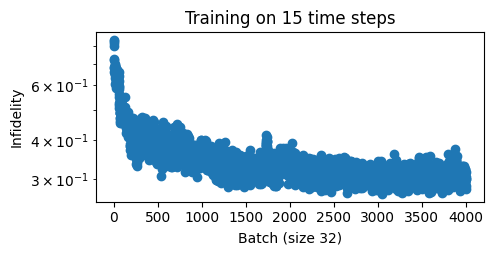

In [ ]:
fig, ax = plt.subplots(figsize=(5, 2.2))

ff = jnp.array(mean_fids_train)

ax.scatter(jnp.arange(len(mean_fids_train)), 1 - ff);
ax.set_xlabel(f"Batch (size {batch_size})");
ax.set_ylabel("Infidelity");
ax.set_title(f"Training on {num_time_steps_train} time steps");
ax.set_yscale("log");

#fig.savefig("train.pdf", bbox_inches="tight");

In [ ]:
save_flax_state("trained_nn20_20bs_0_plus_4", flax_state)


In [ ]:
key, subkey = jax.random.split(key)
traj_out = test_on_batch(subkey, flax_state)
fids, meas_outs, probs = traj_out

In [ ]:
import numpy as np

In [ ]:
x = np.arange(2)

In [ ]:
def func(a, b):
    return a + b

In [ ]:
res = func(*x)

In [ ]:
type()

TypeError: type() takes 1 or 3 arguments

In [ ]:
ctrl = jnp.arange(3.0)

In [ ]:
action_numpy_reshaped = (elem.item() for elem in ctrl.reshape(-1))

In [ ]:
type(l[0])

NameError: name 'l' is not defined

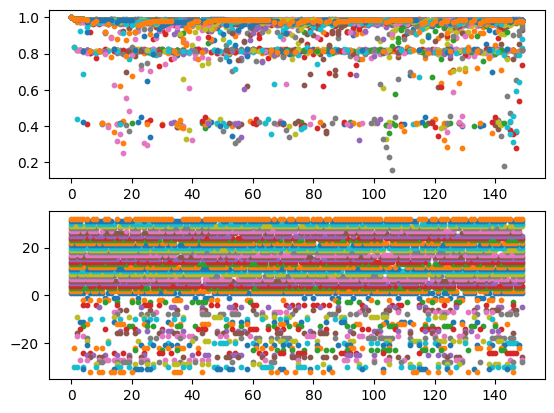

In [ ]:
fig, axes = plt.subplots(2, 1)
    
for f in fids[:]:
    axes[0].scatter(jnp.arange(len(f)), f, s=10);
    
for i, m in enumerate(meas_outs[:]):
    axes[1].scatter(jnp.arange(len(m)), m*(i+1), s=10);
    
#fig.savefig("apply.pdf", bbox_inches="tight");

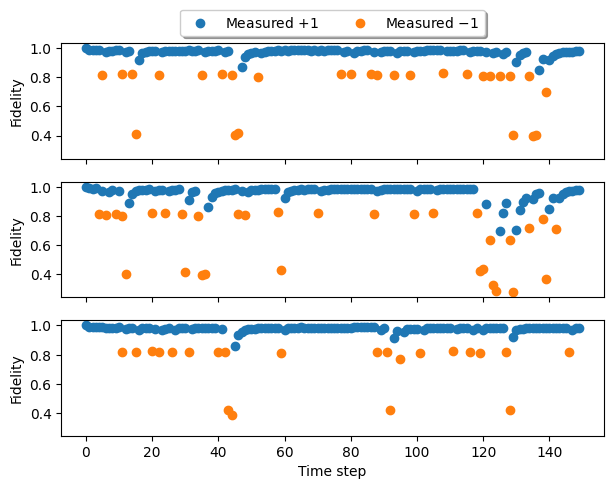

In [ ]:
test_indx = [0, 1, 2]

fig, axes = plt.subplots(len(test_indx), 1, figsize=(7, 1.7 * len(test_indx)), sharex=True, sharey=True)

for ax, ti in zip(axes, test_indx):
    f = fids[ti]
    m = meas_outs[ti]
    arng = jnp.arange(len(f))
    ax.scatter(arng[m==1], f[m==1], label=r"Measured $+1$");
    ax.scatter(arng[m==-1], f[m==-1], label=r"Measured $-1$");
    ax.set_ylabel("Fidelity");
    
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.35),
          fancybox=True, shadow=True, ncol=5);
ax.set_xlabel("Time step");
ax.set_title("");

#fig.savefig("stabilize.pdf", bbox_inches="tight");

In [ ]:
idle = make_idle(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
fidelity_cav = make_fidelity_cav(psi_target_cav)

psi_init = tensor(basis(2, 1), psi_target_cav)
rho_init = psi_init @ hconj(psi_init)

In [ ]:
rho = rho_init
fids_nostab = []

for i in range(num_time_steps_test):
    rho = idle(rho)
    f = fidelity_cav(rho)
    fids_nostab.append(f)
    
fids_nostab = jnp.array(fids_nostab)

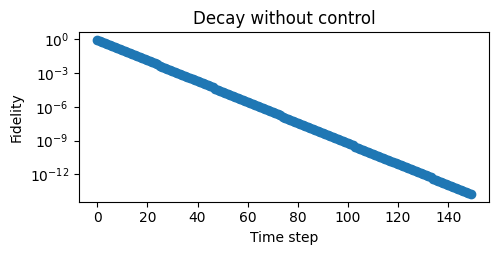

In [ ]:
fig, ax = plt.subplots(figsize=(5.3, 2.2))
ax.scatter(jnp.arange(len(fids_nostab)), fids_nostab);
ax.set_yscale("log");
ax.set_ylabel("Fidelity");
ax.set_xlabel("Time step");
ax.set_title("Decay without control");

#fig.savefig("noctrl.pdf", bbox_inches="tight");

In [ ]:
fids_nostab

Array([8.29688668e-01, 6.85570478e-01, 5.64531922e-01, 4.63501632e-01,
       3.79601687e-01, 3.10224175e-01, 2.53061354e-01, 2.06105977e-01,
       1.67635322e-01, 1.36186123e-01, 1.10525712e-01, 8.96227583e-02,
       7.26191476e-02, 5.88041842e-02, 4.75916006e-02, 3.84993032e-02,
       3.11319977e-02, 2.51663420e-02, 2.03383639e-02, 1.64329652e-02,
       1.32751120e-02, 1.07225738e-02, 8.65989458e-03, 6.99344743e-03,
       5.64736640e-03, 4.56022099e-03, 3.68230231e-03, 2.97340099e-03,
       2.40101130e-03, 1.93886145e-03, 1.56572601e-03, 1.26445899e-03,
       1.02121441e-03, 8.24812043e-04, 6.66225096e-04, 5.38166438e-04,
       4.34753543e-04, 3.51238123e-04, 2.83787260e-04, 2.29306956e-04,
       1.85299781e-04, 1.49749714e-04, 1.21029268e-04, 9.78245516e-05,
       7.90747872e-05, 6.39234713e-05, 5.16790242e-05, 4.17829579e-05,
       3.37842575e-05, 2.73186397e-05, 2.20918737e-05, 1.78662722e-05,
       1.44498190e-05, 1.16873798e-05, 9.45360171e-06, 7.64719243e-06,
      